<a href="https://colab.research.google.com/github/Ayaawasis-collab/Projek-Anreg/blob/main/Topik_Statistika_Wasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TOPIK DALAM STATISTIKA

#Simulasi data

In [ ]:
# SIMULASI DAN ANALISIS AR(1)

# 1. Import library
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Fungsi simulasi AR(1)
def simulate_ar1(phi, mu, n, sigma=1.0):
    Y = np.zeros(n)
    Y[0] = mu / (1 - phi)
    et = np.random.normal(0, sigma, n)

    for t in range(1, n):
        Y[t] = mu + phi * Y[t-1] + et[t]

    return Y

# 3. Parameter simulasi
np.random.seed(123)
n = 100
phi = 0.2
mu = 1

# 4. Generate data
Y = simulate_ar1(phi, mu, n)
print(Y)


[ 1.25        2.24734545  1.73244759 -0.1598052   0.38943871  2.72932428
 -0.88081439  0.39492449  2.34492116  0.60224383  0.44156261  0.99360355
  2.69011034  0.89912007  0.73584205  0.71281714  3.34849351  3.85648479
  2.77535086  1.94125657  2.12561989  2.91585601  0.64733733  2.30529651
  0.20717863  0.40368422  1.98784204 -0.03111229  0.85370882  0.30898687
  0.806178   -1.6373535  -1.09900381  0.080322    1.94352683  1.21506968
  1.24585985  1.93739468  0.50794259  1.38521584  0.47167665 -0.63333416
  0.48243337  1.67029254  1.67264756  1.32269902  3.65690507  2.14429317
  2.40759464  3.71966227  0.44984713  0.05118122  2.75394847  0.75272696
  1.18022862  2.30536169  2.35177873  3.22524193  3.14069252  2.69753117
  0.76679752  1.94822217  1.70391643  0.01451783  2.42020261  2.29127706
  1.50374549  1.06765704  0.01523026  1.20257013  1.70895314  0.51063564
  2.26433118  0.35566319 -1.05196771  1.82933355  0.96250067  1.06647055
  0.37577739 -0.53080728  2.14907592  0.7409462   2

#Visualisasi data

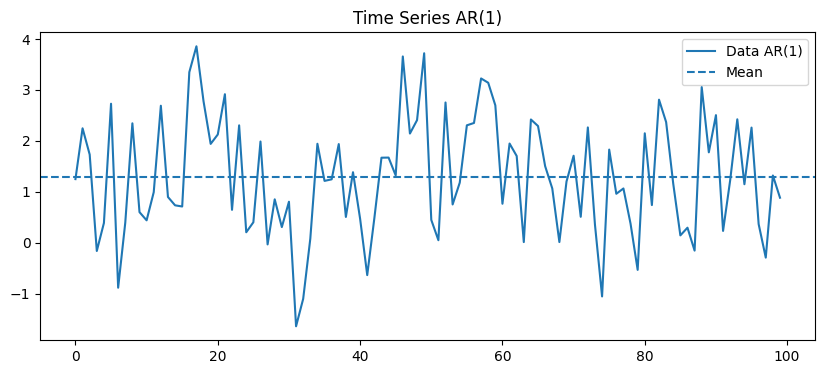

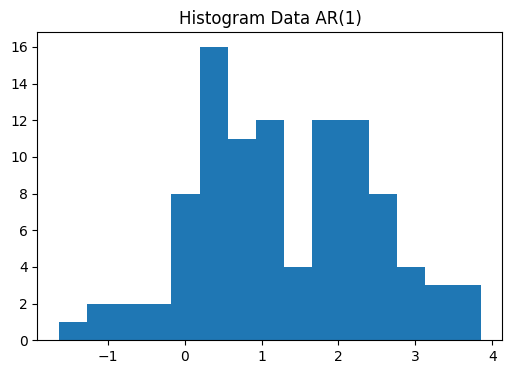

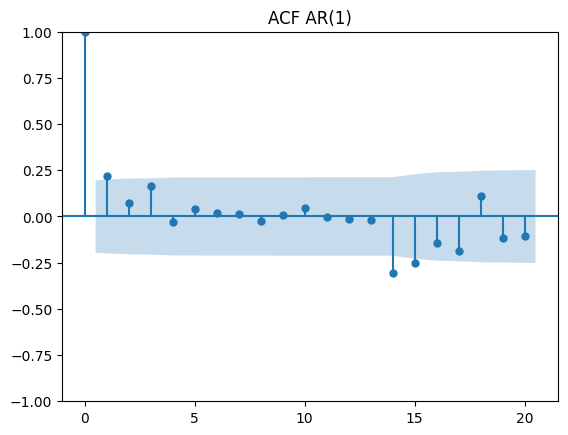

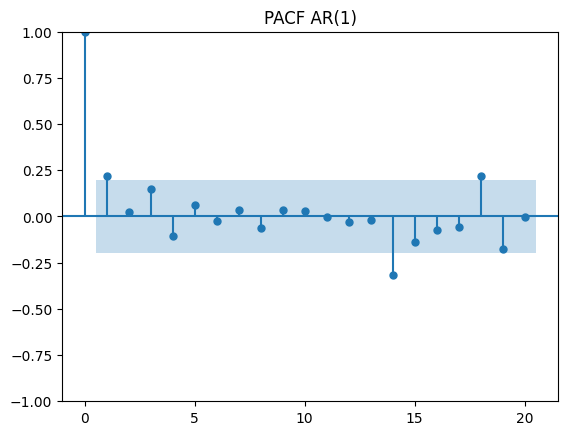

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  100
Model:                     AutoReg(1)   Log Likelihood                -152.408
Method:               Conditional MLE   S.D. of innovations              1.128
Date:                Wed, 15 Apr 2026   AIC                            310.816
Time:                        01:24:07   BIC                            318.601
Sample:                             1   HQIC                           313.966
                                  100                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0122      0.171      5.925      0.000       0.677       1.347
y.L1           0.2201      0.098      2.244      0.025       0.028       0.412
                                    Roots           

In [ ]:
# VISUALISASI DATA

# 5. Plot time series
plt.figure(figsize=(10,4))
plt.plot(Y, label='Data AR(1)')
plt.axhline(np.mean(Y), linestyle='--', label='Mean')
plt.title("Time Series AR(1)")
plt.legend()
plt.show()

# 6. Histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=15)
plt.title("Histogram Data AR(1)")
plt.show()

# 7. ACF , PACF
plot_acf(Y)
plt.title("ACF AR(1)")
plt.show()

plot_pacf(Y)
plt.title("PACF AR(1)")
plt.show()

# ESTIMASI MODEL AR(1)

model = AutoReg(Y, lags=1).fit()
print(model.summary())


#EACF

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conver


=== TABEL EACF ===
          MA(0)     MA(1)     MA(2)     MA(3)     MA(4)     MA(5)
AR(0)  0.219827  0.000137  0.000016 -0.009452 -0.000154  0.003040
AR(1) -0.003160  0.014347  0.011415  0.002428  0.002215  0.002470
AR(2) -0.001520  0.006081  0.012145  0.001986  0.002300 -0.017010
AR(3)  0.017929  0.000442  0.001864  0.001885  0.001914  0.001524
AR(4)  0.008705  0.002316  0.001320 -0.000185 -0.008051  0.002125
AR(5)  0.003691  0.002207  0.002425 -0.008827  0.006173  0.002638


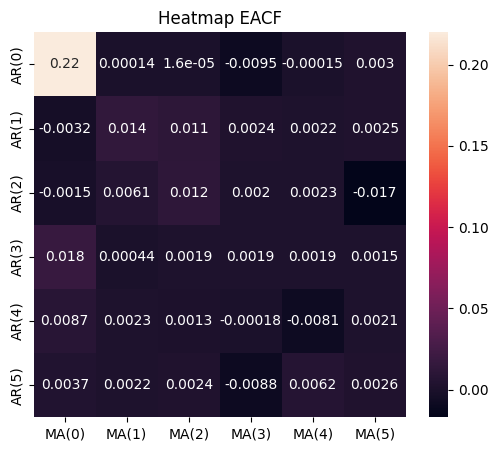

In [ ]:
# EACF (Extended Autocorrelation Function)

import pandas as pd
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.arima.model import ARIMA

def compute_eacf(series, max_ar=5, max_ma=5):
    """
    Menghitung tabel EACF sederhana
    """
    eacf_table = np.zeros((max_ar+1, max_ma+1))

    for p in range(max_ar+1):
        for q in range(max_ma+1):
            try:
                model = ARIMA(series, order=(p,0,q)).fit()
                resid = model.resid
                acf_vals = acf(resid, nlags=1)

                # Ambil nilai lag-1 ACF residual
                eacf_table[p,q] = acf_vals[1]
            except:
                eacf_table[p,q] = np.nan

    return pd.DataFrame(eacf_table,
                        index=[f"AR({i})" for i in range(max_ar+1)],
                        columns=[f"MA({j})" for j in range(max_ma+1)])

# Hitung EACF
eacf_result = compute_eacf(Y, max_ar=5, max_ma=5)

print("\n=== TABEL EACF ===")
print(eacf_result)

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(eacf_result, annot=True)
plt.title("Heatmap EACF")
plt.show()


#Visualisasi hasil model

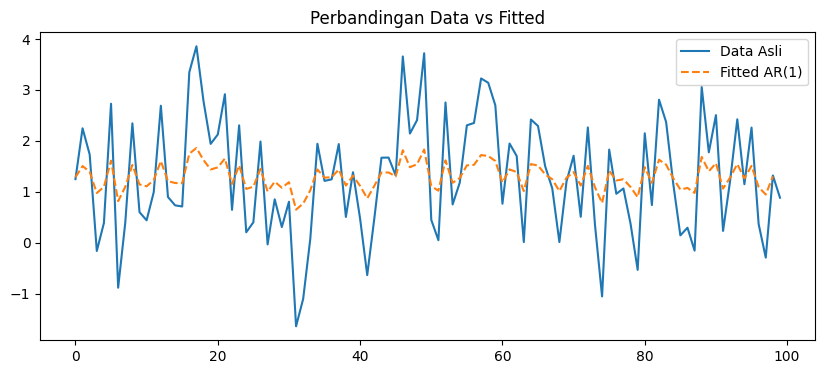

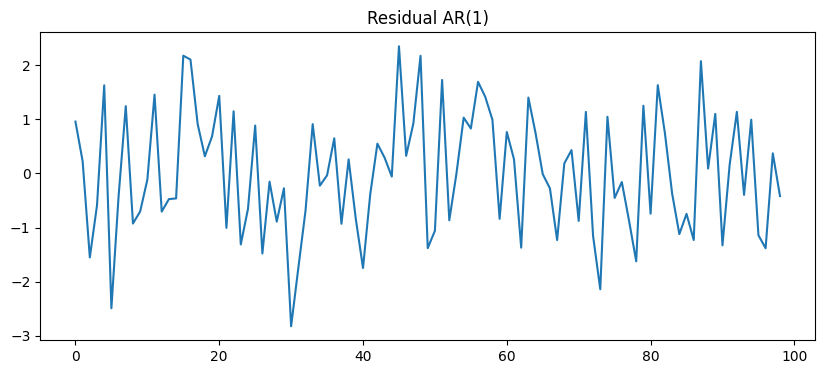


=== INTERPRETASI ===
Parameter asli: phi = 0.2 , mu = 1
Parameter estimasi:
[1.01215146 0.2201125 ]

Kesimpulan:
- Jika koefisien lag mendekati 0.2 → model sesuai AR(1)
- Jika PACF cut-off di lag 1 → indikasi AR(1)
- Jika residual acak → model sudah baik


In [ ]:
# VISUALISASI HASIL MODEL

# 8. Plot fitted vs data asli
fitted = model.fittedvalues

plt.figure(figsize=(10,4))
plt.plot(Y, label='Data Asli')
plt.plot(fitted, linestyle='--', label='Fitted AR(1)')
plt.title("Perbandingan Data vs Fitted")
plt.legend()
plt.show()

# 9. Plot residual
residuals = model.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residual AR(1)")
plt.show()

#Interpretasi

print("\n=== INTERPRETASI ===")
print("Parameter asli: phi =", phi, ", mu =", mu)
print("Parameter estimasi:")
print(model.params)

print("\nKesimpulan:")
print("- Jika koefisien lag mendekati 0.2 → model sesuai AR(1)")
print("- Jika PACF cut-off di lag 1 → indikasi AR(1)")
print("- Jika residual acak → model sudah baik")